# Resumen del EDA de Yelp orientado a modelado

Esta notebook resume los hallazgos principales del EDA de Yelp y conserva la parte de modelado con **regresión lineal** y **random forest** como base para aprendizaje automático. La idea es tener una versión más corta, enfocada en las señales útiles para predicción.

In [49]:
import gc
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

def find_datasets_dir(folder_name: str = 'datasets') -> Path:
    start = Path.cwd()
    for d in (start, *start.parents):
        candidate = d / folder_name
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError(f"No se encontró la carpeta '{folder_name}' desde {start}")


def read_json_sample(path, nrows=100_000):
    return pd.read_json(path, lines=True, nrows=nrows)

BASE_PATH = find_datasets_dir()
SAMPLE_ROWS = 100_000
print(f'Datasets encontrados en: {BASE_PATH}')
print(f'Versión resumida trabajando con una muestra de hasta {SAMPLE_ROWS:,} filas por archivo grande.')

Datasets encontrados en: d:\aprendizaje_maquina\datasets
Versión resumida trabajando con una muestra de hasta 100,000 filas por archivo grande.


In [50]:
print('Cargando datasets (muestra resumida)...')

df_user = read_json_sample(BASE_PATH / 'yelp_academic_dataset_user.json', nrows=SAMPLE_ROWS)
df_review = read_json_sample(BASE_PATH / 'yelp_academic_dataset_review.json', nrows=SAMPLE_ROWS)
df_tip = read_json_sample(BASE_PATH / 'yelp_academic_dataset_tip.json', nrows=SAMPLE_ROWS)
df_business = read_json_sample(BASE_PATH / 'yelp_academic_dataset_business.json', nrows=SAMPLE_ROWS)
df_checkin = read_json_sample(BASE_PATH / 'yelp_academic_dataset_checkin.json', nrows=SAMPLE_ROWS)
df_checkin['n_checkins'] = df_checkin['date'].fillna('').apply(lambda x: 0 if not str(x).strip() else str(x).count(',') + 1)

print('Carga finalizada.')

datasets_dict = {
    'Users (muestra)': df_user,
    'Reviews (muestra)': df_review,
    'Tips (muestra)': df_tip,
    'Check-ins (muestra)': df_checkin,
    'Business (muestra)': df_business,
}

summary_datasets = pd.DataFrame({
    'Dataset': list(datasets_dict.keys()),
    'Filas': [len(df) for df in datasets_dict.values()],
    'Columnas': [df.shape[1] for df in datasets_dict.values()],
    'NaN totales': [int(df.isna().sum().sum()) for df in datasets_dict.values()],
})

display(summary_datasets)

Cargando datasets (muestra resumida)...
Carga finalizada.


,Dataset,Filas,Columnas,NaN totales
0,Users (muestra),100000,22,0
1,Reviews (muestra),100000,9,0
2,Tips (muestra),100000,5,0
3,Check-ins (muestra),100000,3,0
4,Business (muestra),100000,14,24590


,Métrica,Valor
0,Total de usuarios,"100,000"
1,Antigüedad media (años),14.07
2,Reviews por usuario (media),92.63
3,Fans por usuario (media),7.48
4,Amigos por usuario (media),126.08
5,% usuarios elite (alguna vez),100.00 %
6,Estrellas promedio (media),3.8532


,Métrica,Valor
0,Total de reviews,"100,000"
1,Estrellas promedio,3.8429
2,Texto promedio (caracteres),548.4
3,Useful promedio,0.90
4,Funny promedio,0.26
5,Cool promedio,0.35


,Métrica,Valor
0,Total de negocios,"100,000"
1,Estrellas promedio,3.5972
2,Negocios abiertos (%),79.62 %
3,Categorías faltantes,69


,Métrica,Valor
0,Total de negocios con check-ins,"100,000"
1,Check-ins totales,"10,244,361"
2,Check-ins por negocio (media),102.44
3,Check-ins por negocio (mediana),20.00


C:\Users\jpcas\AppData\Local\Temp\ipykernel_15700\2620090018.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=elite_counts.index, y=elite_counts.values, palette='viridis', ax=ax)


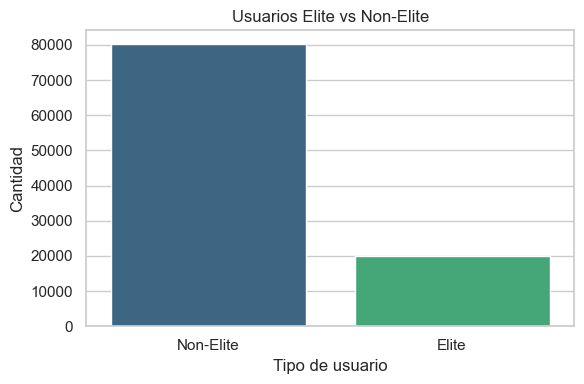

In [51]:
# Resumen EDA compacto para dejar listas las señales útiles para ML

df_user['elite'] = df_user['elite'].apply(lambda x: 'Elite' if isinstance(x, str) and len(x) > 0 else 'Non-Elite')
df_user['yelping_since'] = pd.to_datetime(df_user['yelping_since'])
df_user['years_active'] = (pd.Timestamp('2026-05-31') - df_user['yelping_since']).dt.days / 365.25
df_user['friend_count'] = df_user['friends'].apply(lambda x: 0 if (x == 'None' or x == '') else len(str(x).split(',')))
df_user['elite_years'] = df_user['elite'].apply(lambda x: 0 if (x == '' or pd.isna(x)) else len(str(x).split(',')))
compliment_cols = [c for c in df_user.columns if c.startswith('compliment_')]
df_user['total_compliments'] = df_user[compliment_cols].sum(axis=1)

user_summary = pd.DataFrame({
    'Métrica': [
        'Total de usuarios',
        'Antigüedad media (años)',
        'Reviews por usuario (media)',
        'Fans por usuario (media)',
        'Amigos por usuario (media)',
        '% usuarios elite (alguna vez)',
        'Estrellas promedio (media)',
    ],
    'Valor': [
        f"{len(df_user):,}",
        f"{df_user['years_active'].mean():.2f}",
        f"{df_user['review_count'].mean():.2f}",
        f"{df_user['fans'].mean():.2f}",
        f"{df_user['friend_count'].mean():.2f}",
        f"{(df_user['elite_years'] > 0).mean() * 100:.2f} %",
        f"{df_user['average_stars'].mean():.4f}",
    ]
})

review_summary = pd.DataFrame({
    'Métrica': [
        'Total de reviews',
        'Estrellas promedio',
        'Texto promedio (caracteres)',
        'Useful promedio',
        'Funny promedio',
        'Cool promedio',
    ],
    'Valor': [
        f"{len(df_review):,}",
        f"{df_review['stars'].mean():.4f}",
        f"{df_review['text'].str.len().mean():.1f}",
        f"{df_review['useful'].mean():.2f}",
        f"{df_review['funny'].mean():.2f}",
        f"{df_review['cool'].mean():.2f}",
    ]
})

business_summary = pd.DataFrame({
    'Métrica': [
        'Total de negocios',
        'Estrellas promedio',
        'Negocios abiertos (%)',
        'Categorías faltantes',
    ],
    'Valor': [
        f"{len(df_business):,}",
        f"{df_business['stars'].mean():.4f}",
        f"{df_business['is_open'].mean() * 100:.2f} %",
        f"{int(df_business['categories'].isna().sum()):,}",
    ]
})

checkins_per_business = df_checkin.set_index('business_id')['n_checkins']
checkin_summary = pd.DataFrame({
    'Métrica': [
        'Total de negocios con check-ins',
        'Check-ins totales',
        'Check-ins por negocio (media)',
        'Check-ins por negocio (mediana)',
    ],
    'Valor': [
        f"{len(df_checkin):,}",
        f"{checkins_per_business.sum():,}",
        f"{checkins_per_business.mean():.2f}",
        f"{checkins_per_business.median():.2f}",
    ]
})

display(user_summary)
display(review_summary)
display(business_summary)
display(checkin_summary)

fig, ax = plt.subplots(figsize=(6, 4))
elite_counts = df_user['elite'].value_counts()
sns.barplot(x=elite_counts.index, y=elite_counts.values, palette='viridis', ax=ax)
ax.set_title('Usuarios Elite vs Non-Elite')
ax.set_xlabel('Tipo de usuario')
ax.set_ylabel('Cantidad')
plt.tight_layout()
plt.show()

## Enfoque de modelado

Con el EDA resumido, el objetivo de modelado se centra en predecir el volumen de visitas del negocio (`n_checkins`). La variable objetivo es muy asimétrica, por eso se trabaja en escala `log1p` y luego se revierten las predicciones con `expm1`.

Las variables se mantienen deliberadamente simples e interpretables para comparar un baseline lineal contra un modelo no lineal como random forest.

In [52]:
# Dataset de modelado para predecir n_checkins

biz = df_business[['business_id', 'stars', 'review_count', 'state', 'city', 'is_open', 'attributes', 'hours']].copy()
biz = biz.set_index('business_id').join(checkins_per_business.rename('n_checkins'), how='inner')

def n_attributes(attr):
    if isinstance(attr, dict):
        return len(attr)
    return 0


def n_days_open(hours):
    if isinstance(hours, dict):
        return sum(1 for v in hours.values() if v and str(v).strip() != '0:0-0:0')
    return 0

biz['n_attributes'] = biz['attributes'].apply(n_attributes)
biz['n_days_open'] = biz['hours'].apply(n_days_open)

le_state = LabelEncoder()
biz['state_enc'] = le_state.fit_transform(biz['state'].fillna('Unknown'))
city_freq = biz['city'].value_counts()
biz['city_freq'] = biz['city'].map(city_freq).fillna(1)

feature_cols = ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
X = biz[feature_cols].fillna(0).astype(float)
y_log = np.log1p(biz['n_checkins'])
y_raw = biz['n_checkins']

print(f'Features: {feature_cols}')
print(f'Target n_checkins: media={y_raw.mean():.1f} | mediana={y_raw.median():.1f} | max={y_raw.max():,}')
print(f'log1p(n_checkins): media={y_log.mean():.3f} | std={y_log.std():.3f} | skew={y_log.skew():.3f}')


Features: ['stars', 'review_count', 'is_open', 'n_attributes', 'n_days_open', 'state_enc', 'city_freq']
Target n_checkins: media=104.8 | mediana=20.0 | max=52,144
log1p(n_checkins): media=3.182 | std=1.625 | skew=0.446



Métricas comparativas:


,MAE (log),RMSE (log),R² (log),MAE (orig),RMSE (orig)
Regresión lineal,0.9747,1.2360,0.4180,12739369.8736,1207100916.8341
Random Forest,0.7697,0.9831,0.6318,58.4685,394.6972



Mejor modelo según R² en log: Random Forest


,Importancia
review_count,0.7864
n_attributes,0.0788
city_freq,0.0393
stars,0.0379
n_days_open,0.0272
state_enc,0.0251
is_open,0.0053


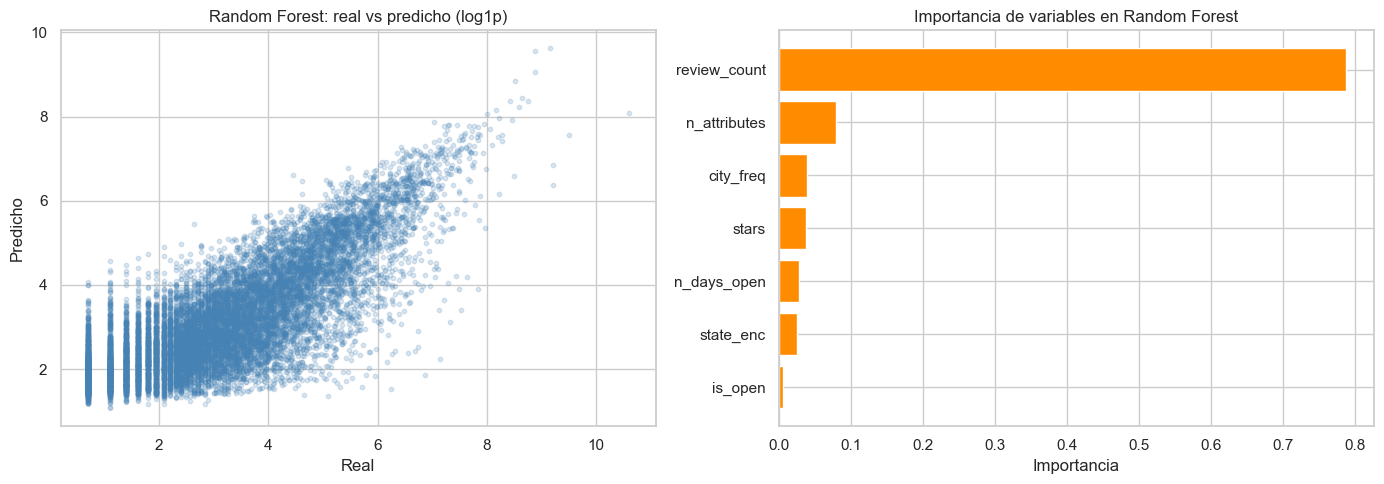

In [53]:
# Baseline lineal vs random forest

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
y_test_raw = np.expm1(y_test)

models = {
    'Regresión lineal': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1),
}

results = {}
fitted = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred_log = model.predict(X_test)
    pred_raw = np.expm1(pred_log)
    fitted[name] = {'model': model, 'pred_log': pred_log, 'pred_raw': pred_raw}
    results[name] = {
        'MAE (log)': mean_absolute_error(y_test, pred_log),
        'RMSE (log)': np.sqrt(mean_squared_error(y_test, pred_log)),
        'R² (log)': r2_score(y_test, pred_log),
        'MAE (orig)': mean_absolute_error(y_test_raw, pred_raw),
        'RMSE (orig)': np.sqrt(mean_squared_error(y_test_raw, pred_raw)),
    }

metrics = pd.DataFrame(results).T
print('\nMétricas comparativas:')
display(metrics.round(4))

best_name = metrics['R² (log)'].idxmax()
print(f'\nMejor modelo según R² en log: {best_name}')

rf = fitted['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(importances.to_frame('Importancia'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, fitted['Random Forest']['pred_log'], alpha=0.2, s=10, color='steelblue')
axes[0].set_title('Random Forest: real vs predicho (log1p)')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Predicho')

axes[1].barh(importances.index[::-1], importances.values[::-1], color='darkorange')
axes[1].set_title('Importancia de variables en Random Forest')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

## Cierre

Esta versión resumida deja el foco en dos cosas: los hallazgos del EDA que realmente ayudan a modelar y una comparación directa entre un baseline lineal y random forest. Si querés, el siguiente paso natural es extender esta notebook con un modelo de clasificación o con selección de variables más agresiva.

## JPC 16/08 - Clasificación binaria elite/no elite

# Justificación

Para el departamento de marketing de una marca no tan grande, resulta útil identificar y captar embajadores de la marca antes que se conviertan en personalidades muy populares, ya que una vez que llegan a ése status, pueden ser tentados por marcas muy grandes.

¿Tiene sentido como problema de ML?
* Para entrenar un modelo necesitamos una cantidad suficiente de datos.
    * Utilizamos el dataset de Yelp de usuarios (cientas de miles de observaciones) y tratamos de predecir usuarios candidatos al status "elite" (potenciales embajadores de marca)
* Los datos deben estar disponibles o ser posibles de recolectar.
    * Disponible en Keggle
* La calidad de los datos suele ser más importante que el algoritmo.
    * Se dispone de mas observaciones de las que es prtáctico procesar

Nos quedamos con el dataset df_user y agregamos un atributo "elite_encoded" que es el encoding binario del atributo elite. Además, eliminamos atributos basados en caracteres que no aporten a la clasificación

In [54]:
# Dataset de modelado para predecir elite
df_binclass = df_user
pd.set_option('display.max_columns', None)  # Muestra todas las columnas
pd.set_option('expand_frame_repr', False)   # Evita que salte a otra línea
df_binclass["elite_encoded"] = (df_binclass["elite"] == "Elite").astype(int)
df_binclass = df_binclass.drop(columns=['elite', 'name', 'friends', 'elite_years', 'yelping_since', 'user_id'])
print (df_binclass.head())

   review_count  useful  funny   cool  fans  average_stars  compliment_hot  compliment_more  compliment_profile  compliment_cute  compliment_list  compliment_note  compliment_plain  compliment_cool  compliment_funny  compliment_writer  compliment_photos  years_active  friend_count  total_compliments  elite_encoded
0           585    7217   1259   5994   267         3.9100             250               65                  55               56               18              232               844              467               467                239                180       19.3429         14995               2873              1
1          4333   43091  13066  27281  3138         3.7400            1145              264                 184              157              251             1847              7054             3131              3131               1521               1946       17.3415          4646              20631              1
2           665    2086   1010   1003    52         

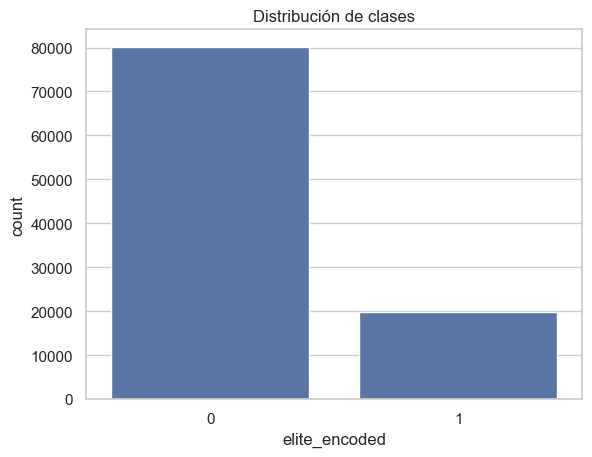

In [55]:
sns.countplot(x='elite_encoded', data=df_binclass)
plt.title('Distribución de clases')
plt.show()

In [56]:
def chequear_correl (df):
    matriz_correl = df.corr(method='pearson')

    plt.figure(figsize=(14,10))
    sns.heatmap(
        matriz_correl,
        cmap='coolwarm',
        annot=True,
        fmt=".2f",
        center=0
    )
    plt.title("Correlación entre atributos")
    plt.show()

    corr = df.corr().abs()

    superior = corr.where(
        np.triu(np.ones(corr.shape), k=1).astype(bool)
    )

    corr_alta = [
        (col, row, superior.loc[row, col])
        for col in superior.columns
        for row in superior.index
        if pd.notna(superior.loc[row, col]) and superior.loc[row, col] > 0.8
    ]

    for c1, c2, corr_val in sorted(corr_alta, key=lambda x: -x[2]):
        print(f"{c1} - {c2}: {corr_val:.3f}")

In [57]:
def rank_correlacionadas(df, target='elite_encoded', threshold=0.8):

    corr_atributos = df.drop(columns=[target]).corr().abs()

    target_corr = (
        df.drop(columns=[target])
          .corrwith(df[target])
          .abs()
    )

    superior = corr_atributos.where(
        np.triu(np.ones(corr_atributos.shape), k=1).astype(bool)
    )

    resultados = []

    for col in superior.columns:
        for row in superior.index:

            corr_value = superior.loc[row, col]

            if pd.notna(corr_value) and corr_value > threshold:

                resultados.append({
                    'feature_1': row,
                    'feature_2': col,
                    'feature_corr': corr_value,
                    'target_corr_1': target_corr[row],
                    'target_corr_2': target_corr[col],
                    'conservar': row if target_corr[row] > target_corr[col] else col
                })

    resultados_df = pd.DataFrame(resultados)

    return resultados_df.sort_values(
        'feature_corr',
        ascending=False
    )

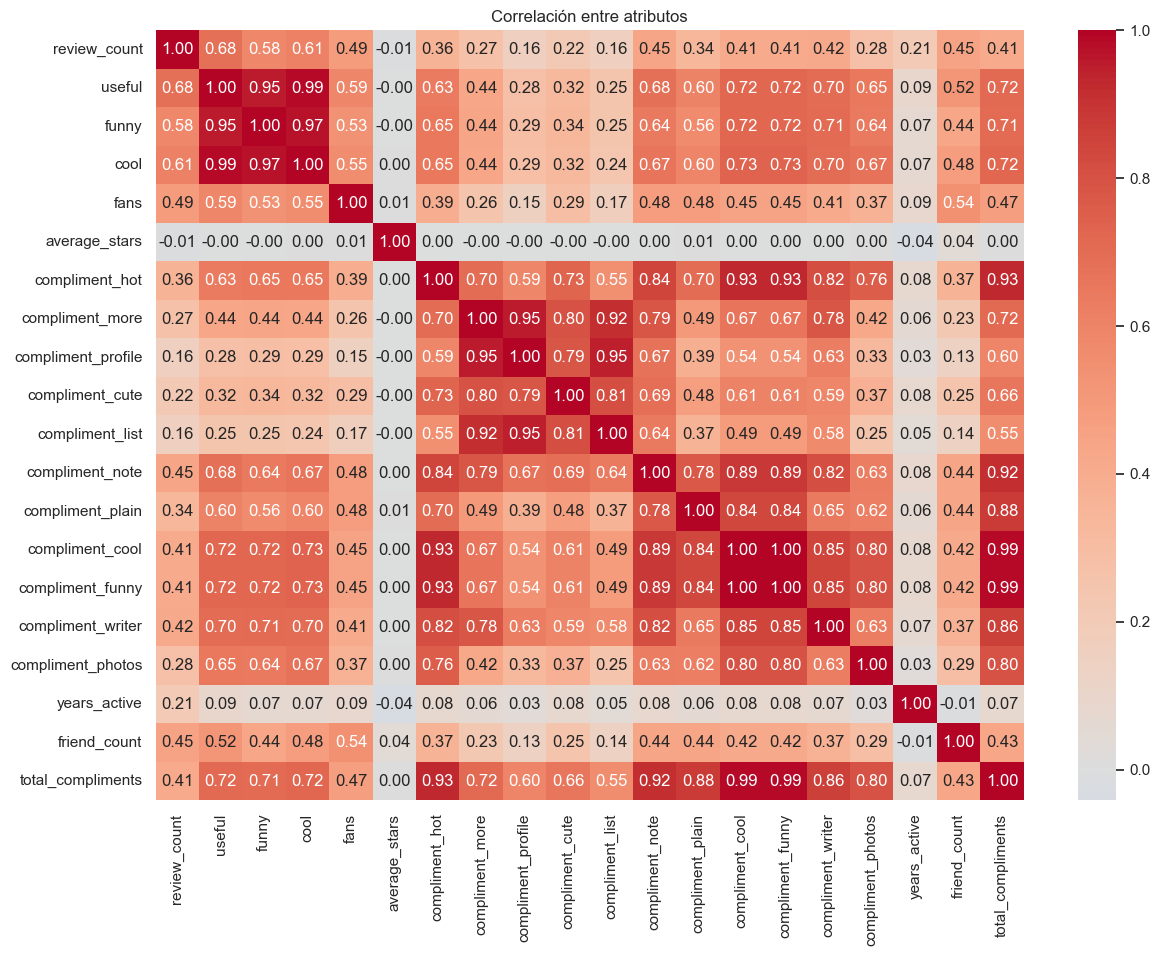

compliment_funny - compliment_cool: 1.000
cool - useful: 0.991
total_compliments - compliment_cool: 0.987
total_compliments - compliment_funny: 0.987
cool - funny: 0.970
funny - useful: 0.955
compliment_profile - compliment_more: 0.954
compliment_list - compliment_profile: 0.948
compliment_cool - compliment_hot: 0.932
compliment_funny - compliment_hot: 0.932
total_compliments - compliment_hot: 0.929
compliment_list - compliment_more: 0.917
total_compliments - compliment_note: 0.916
compliment_cool - compliment_note: 0.889
compliment_funny - compliment_note: 0.889
total_compliments - compliment_plain: 0.879
total_compliments - compliment_writer: 0.858
compliment_writer - compliment_cool: 0.845
compliment_writer - compliment_funny: 0.845
compliment_note - compliment_hot: 0.844
compliment_cool - compliment_plain: 0.837
compliment_funny - compliment_plain: 0.837
compliment_writer - compliment_hot: 0.817
compliment_writer - compliment_note: 0.816
compliment_list - compliment_cute: 0.814
com

In [58]:
df_dummy = df_binclass.drop(columns=['elite_encoded'])
chequear_correl(df_dummy)

Se observa que muchos atributos son prácticamente lo mismo y otros están muy fuertemente correlacionados. La multicolinealidad puede traer problemas para los modelos lineales, por lo cual es mejor eliminar atributos redundantes.

In [59]:
rank_correlacionadas(df_binclass)

,feature_1,feature_2,feature_corr,target_corr_1,target_corr_2,conservar
15,compliment_cool,compliment_funny,1.0000,0.1541,0.1541,compliment_funny
1,useful,cool,0.9912,0.2112,0.1652,useful
24,compliment_funny,total_compliments,0.9865,0.1541,0.1493,compliment_funny
23,compliment_cool,total_compliments,0.9865,0.1541,0.1493,compliment_cool
2,funny,cool,0.9700,0.1464,0.1652,cool
0,useful,funny,0.9548,0.2112,0.1464,useful
3,compliment_more,compliment_profile,0.9537,0.1080,0.0501,compliment_more
6,compliment_profile,compliment_list,0.9480,0.0501,0.0546,compliment_list
9,compliment_hot,compliment_cool,0.9319,0.1360,0.1541,compliment_cool
12,compliment_hot,compliment_funny,0.9319,0.1360,0.1541,compliment_funny


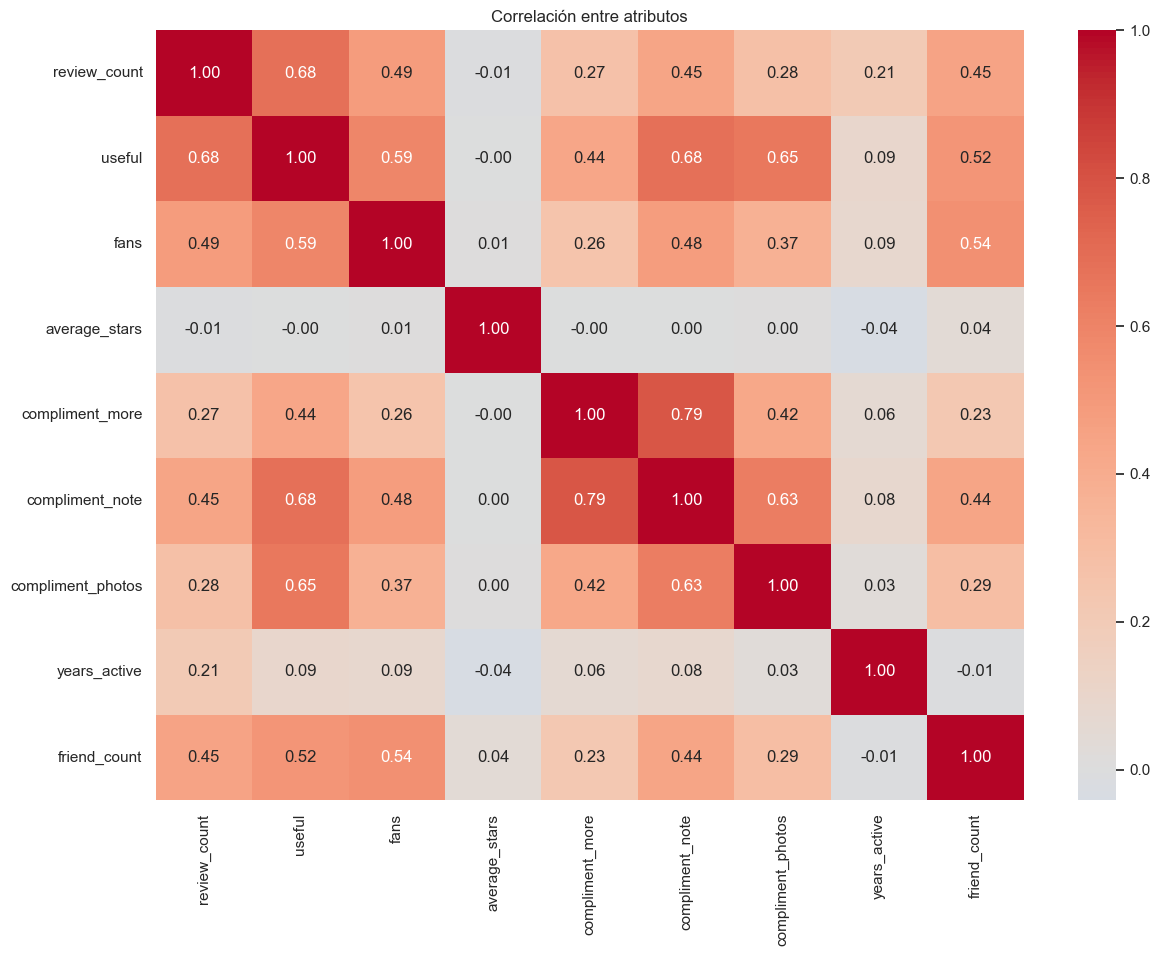

In [60]:
df_binclass = df_binclass.drop(columns=['compliment_cool', 'cool', 'total_compliments', 'funny', 'compliment_profile', 'compliment_hot', 'compliment_list', 'compliment_funny', 'compliment_cool', 'compliment_plain', 'total_compliments', 'compliment_writer', 'compliment_cute'])
df_dummy = df_binclass.drop(columns=['elite_encoded'])
chequear_correl(df_dummy)

Ahora que el dataset está limpio de atributos que podrían llevar a multicolinealidad, evalúo la afinidad de los atributos para predecir el target

In [61]:
from scipy.stats import pointbiserialr

def point_biserial_ranking(df, target='elite_encoded'):

    resultados = []

    for col in df.select_dtypes(include='number').columns:

        if col == target:
            continue

        corr, pvalue = pointbiserialr(df[target], df[col])

        resultados.append({
            'atributo': col,
            'correlación': corr,
            'pvalor': pvalue
        })

    resultados = pd.DataFrame(resultados)

    return resultados.sort_values(
        'correlación',
        key=abs,
        ascending=False
    )

In [62]:
point_biserial_ranking(df_binclass)

,atributo,correlación,pvalor
0,review_count,0.4678,0.0000
8,friend_count,0.2500,0.0000
1,useful,0.2112,0.0000
2,fans,0.2091,0.0000
5,compliment_note,0.1767,0.0000
7,years_active,0.1560,0.0000
4,compliment_more,0.1080,0.0000
6,compliment_photos,0.0898,0.0000
3,average_stars,0.0404,0.0000


Nos quedamos con un dataset mucho mas compacto y liviano. Si consideramos:

| Correlación (\|r\|) | Interpretación |
|---------------------|----------------|
| < 0.1               | Muy débil      |
| 0.1 – 0.3           | Débil          |
| 0.3 – 0.5           | Moderada       |
| > 0.5               | Fuerte         |

Entonces podemos considerar eliminar compliment_photos y average_stars para hacer modelos como SVM mas accesibles. Dado que el análisis punto-biserial no es la única forma de analizar la capacidad de los atributos como predictores del taget, les damos el beneficio de la duda y los dejamos por ahora, pero si mas adelante algún modelo trae problemas, podemos considerar eliminarlos o correr Mutual Information.

## Definición de un baseline para el benchmark

En el EDA completo se observa que hay correlación entre las variables reviews, friends, useful, cool, funny, years_active.

Definimos una heurística que se basa en el cumplimiento de 2 de 3 condiciones de umbral con respecto a reviews, fans y votos useful.

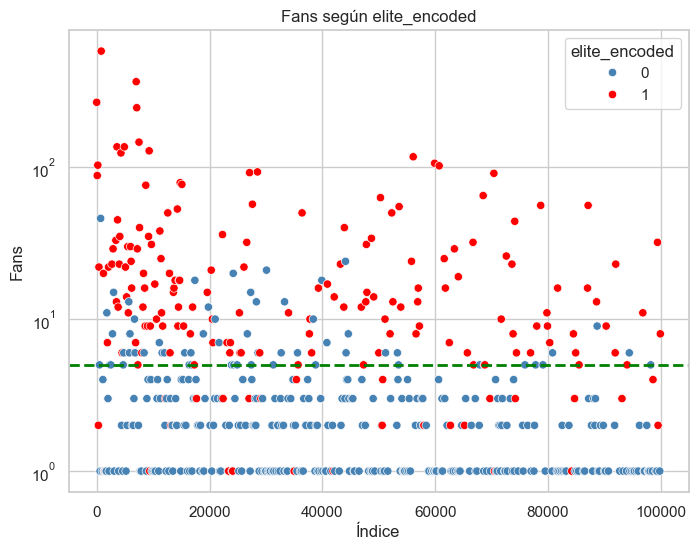

In [63]:
df_plot = df_binclass.iloc[::100]
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_plot,
    x=df_plot.index,
    y="fans",
    hue="elite_encoded",
    palette={0: "steelblue", 1: "red"}
)
plt.axhline(y=5, color='green', linestyle='--', linewidth=2, label='y = 5')
plt.yscale("log")
plt.xlabel("Índice")
plt.ylabel("Fans")
plt.title("Fans según elite_encoded")
plt.show()

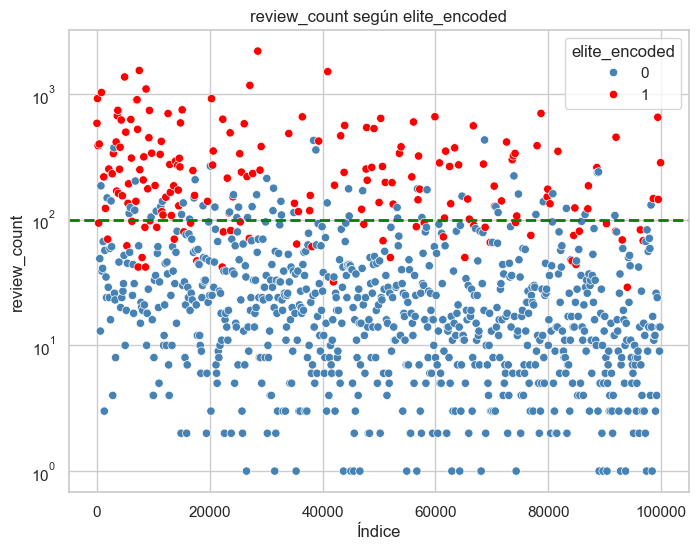

In [64]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_plot,
    x=df_plot.index,
    y="review_count",
    hue="elite_encoded",
    palette={0: "steelblue", 1: "red"}
)
plt.axhline(y=100, color='green', linestyle='--', linewidth=2, label='y = 5')
plt.yscale("log")
plt.xlabel("Índice")
plt.ylabel("review_count")
plt.title("review_count según elite_encoded")
plt.show()

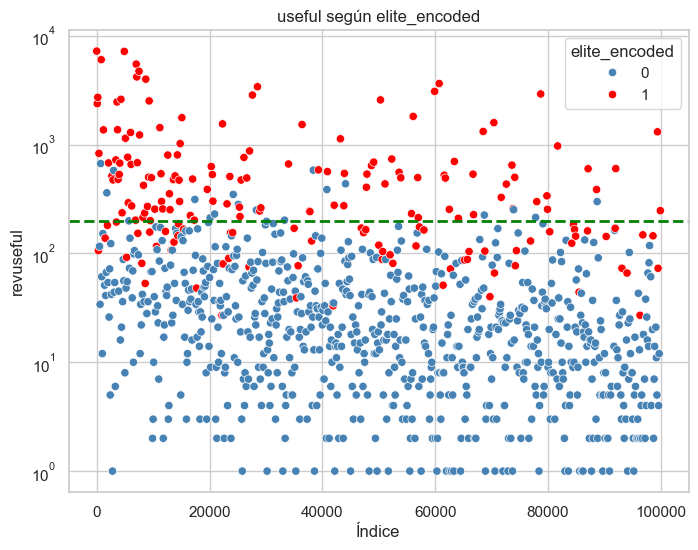

In [65]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df_plot,
    x=df_plot.index,
    y="useful",
    hue="elite_encoded",
    palette={0: "steelblue", 1: "red"}
)
plt.axhline(y=200, color='green', linestyle='--', linewidth=2, label='y = 5')
plt.yscale("log")
plt.xlabel("Índice")
plt.ylabel("revuseful")
plt.title("useful según elite_encoded")
plt.show()

Se elije para la heurística a ojo (2 de 3):
*   más de 100 reviews
*   más de 5 fans
*   más de 200 votos useful

In [66]:
class HeuristicaElite:

    def predict_score(self, X):                                             #Devuelvo un puntaje para ROC-AUC
        return (
            (X["review_count"] > 100).astype(int) +
            (X["fans"] > 5).astype(int) +
            (X["useful"] > 200).astype(int)
        )

    def predict(self, X):
        return (self.predict_score(X) >= 2).astype(int)

In [67]:
X_binclass = df_binclass.drop(columns=["elite_encoded"])
y_binclass = df_binclass["elite_encoded"]

In [68]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_binclass_train, X_binclass_test, y_binclass_train, y_binclass_test = train_test_split(
    X_binclass,
    y_binclass,
    test_size=0.2,
    random_state=42,
    stratify=y_binclass,
)

# Como pretendemos aplicar modelos Regresión Logística, SVM, KNN tenemos que normalizar los atributos

scaler = StandardScaler()

X_binclass_train_scaled = scaler.fit_transform(X_binclass_train)    #Obtengo el escalador con el set de train
X_binclass_test_scaled = scaler.transform(X_binclass_test)          #Aplico el mismo escalador

# Para la heurística no necesitamos entrenamiento y utilizamos el set de test sin normalizar
heuristica = HeuristicaElite()
y_binclass_pred_heur = heuristica.predict(X_binclass_test)

print(f"Exactitud =, {accuracy_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"F1 =, {f1_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"Precisión =, {precision_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"Recall =, {recall_score(y_binclass_test, y_binclass_pred_heur):.4f}")
print(f"ROC-AUC =, {roc_auc_score(y_binclass_test, y_binclass_pred_heur):.4f}")

Exactitud =, 0.9124
F1 =, 0.7647
Precisión =, 0.8201
Recall =, 0.7163
ROC-AUC =, 0.8387


Se ve que la heurística funciona bien y es extremadamente liviana desde el punto de vista de carga computacional asique nos quedamos con ésta

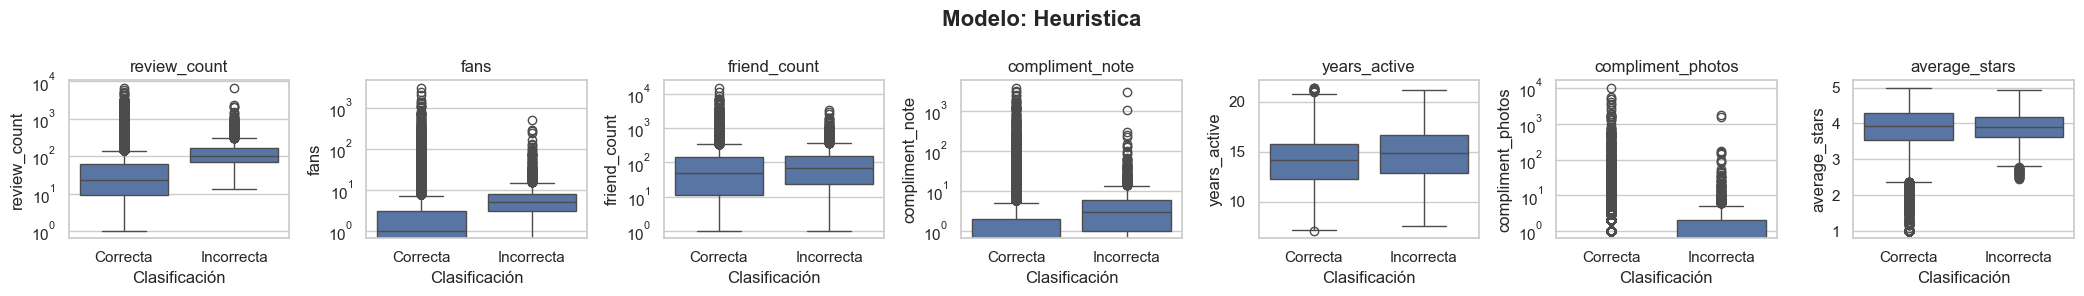

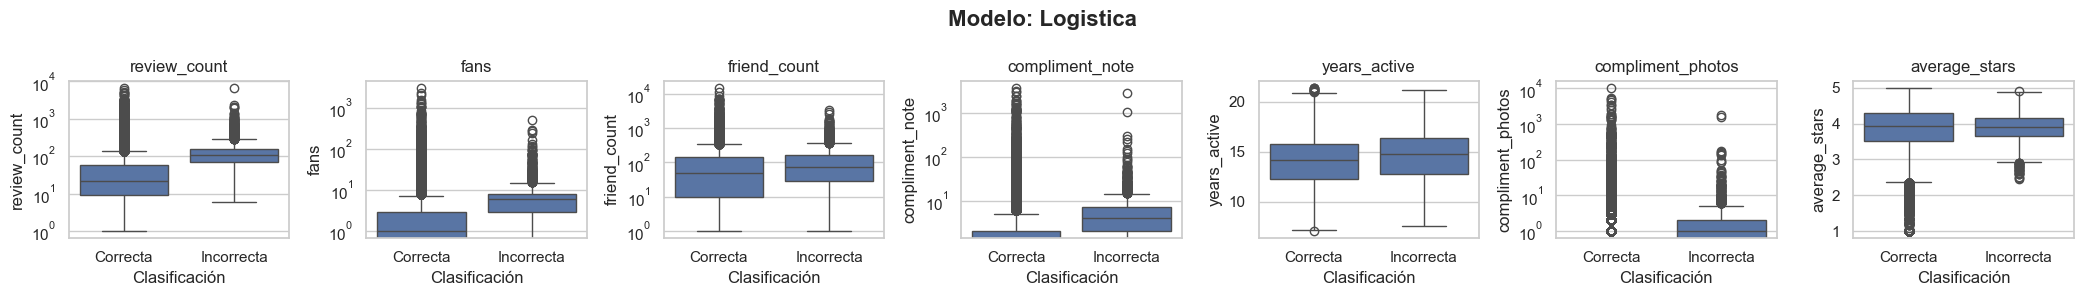

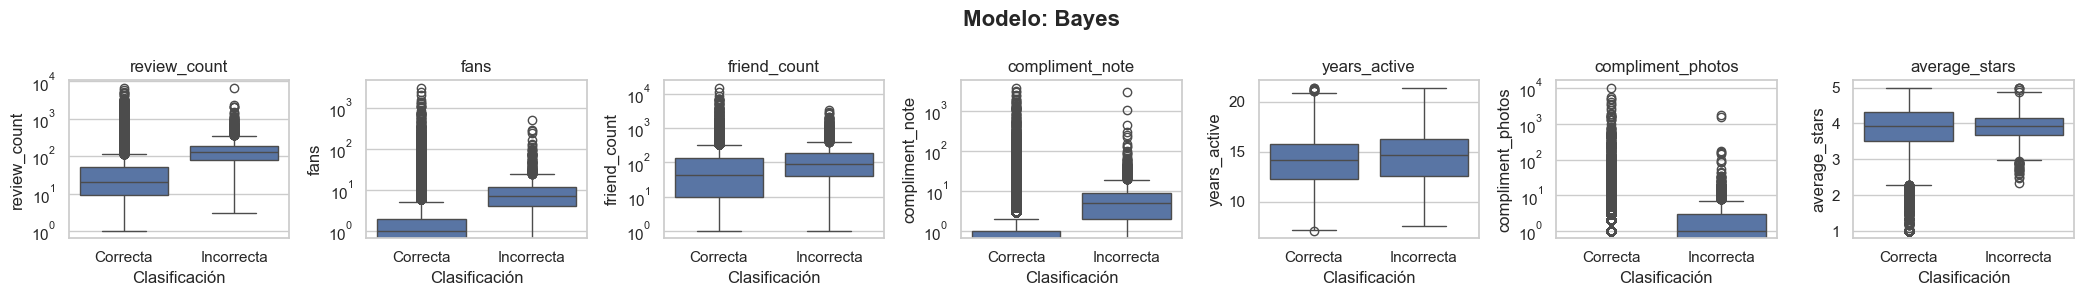

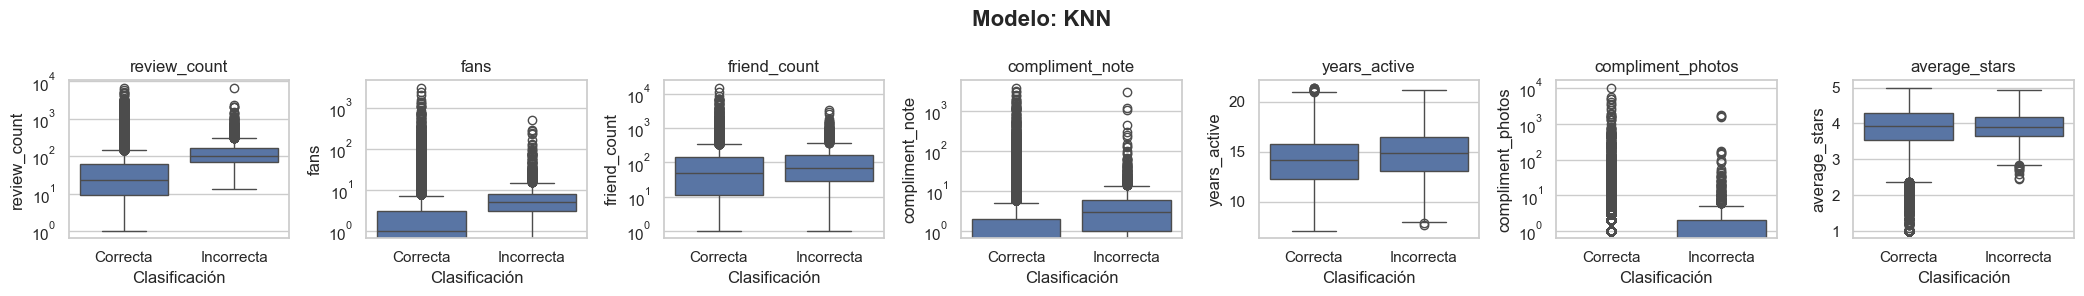

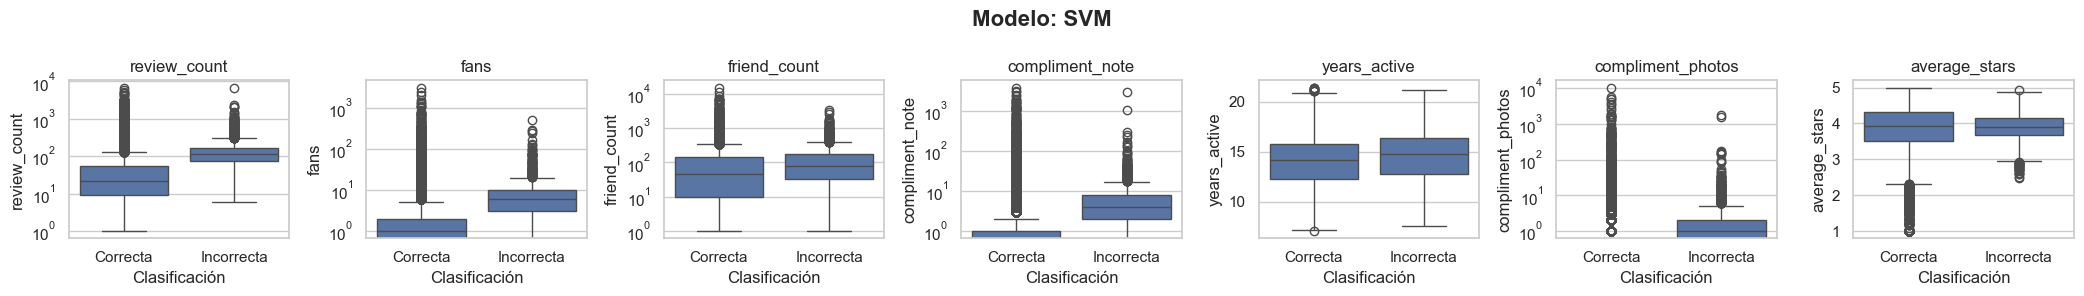

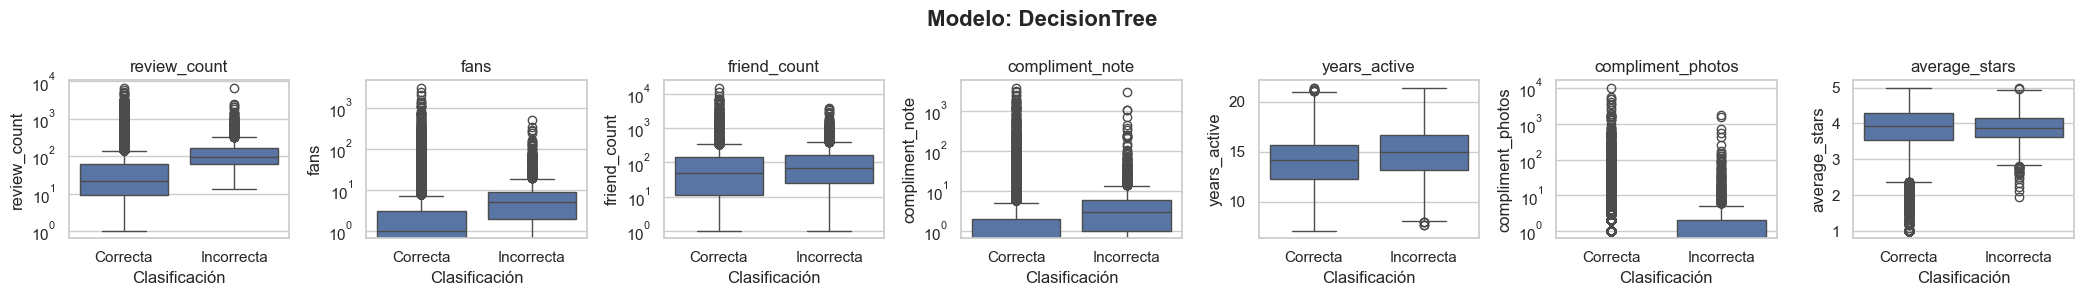

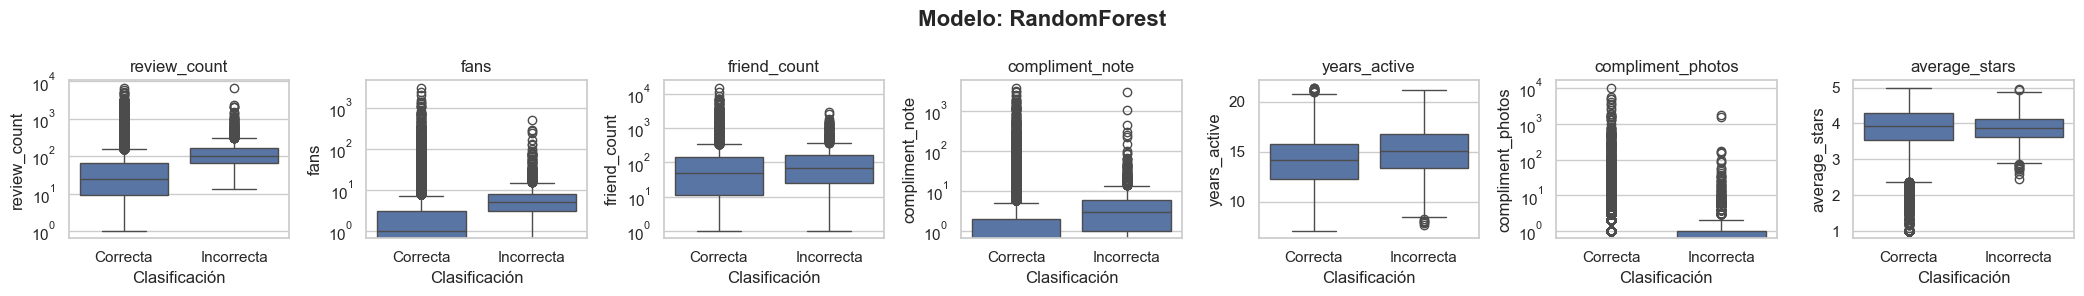

<Figure size 1000x600 with 0 Axes>

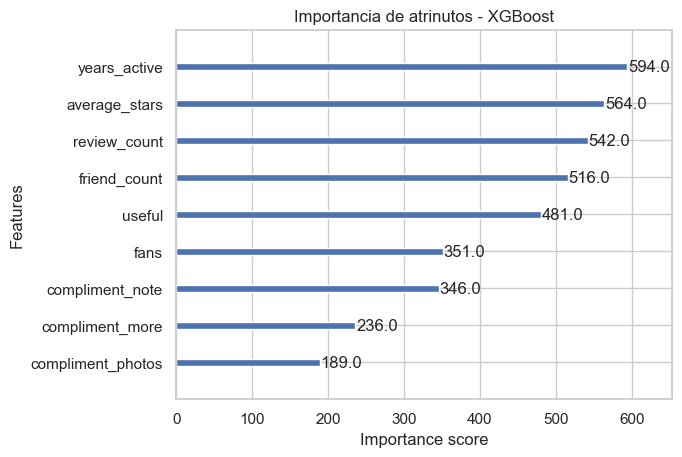

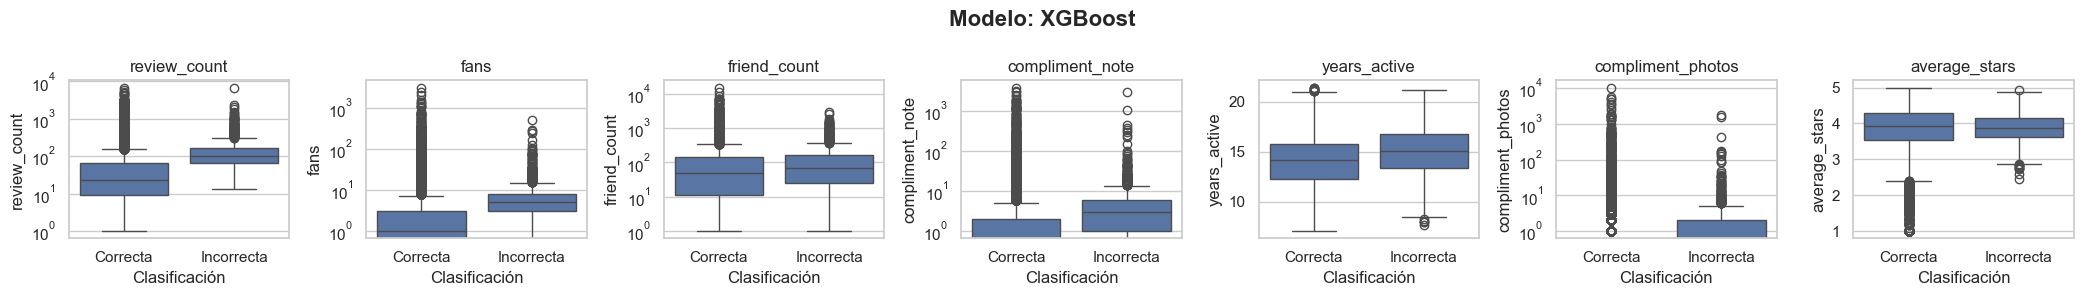


Métricas comparativas:


,Exactitud,F1,Precisión,Recall,ROC-AUC
Heuristica,0.9124,0.7647,0.8201,0.7163,0.9038
Logistica,0.9010,0.7024,0.8714,0.5884,0.9591
Bayes,0.8660,0.5249,0.8878,0.3726,0.9157
KNN,0.9163,0.7756,0.8294,0.7283,0.9367
SVM,0.8871,0.6357,0.8850,0.4960,0.9600
DecisionTree,0.9030,0.7551,0.7577,0.7525,0.8464
RandomForest,0.9328,0.8259,0.8512,0.8021,0.9750
XGBoost,0.9324,0.8265,0.8428,0.8109,0.9761


In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import plot_importance

modelos = {
    "Heuristica": None,
    "Logistica": LogisticRegression(max_iter=1000),
    "Bayes": GaussianNB(var_smoothing=1e-9),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": LinearSVC(random_state=42, max_iter=5000), #SVC(probability=True, random_state=42), #LinearSVC(random_state=42, max_iter=5000)
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(objective='binary:logistic'),
}

atributos = ['review_count', 'fans', 'friend_count', 'compliment_note', 'years_active', 'compliment_photos', 'average_stars']
cant_attr = len(atributos)

results = {}

for nombre, modelo in modelos.items():

    if nombre == "Heuristica":
        y_pred = heuristica.predict(X_binclass_test)
        y_score = heuristica.predict_score(X_binclass_test)

    elif nombre in ["Logistica", "Bayes", "KNN", "SVM"]:
        modelo.fit(X_binclass_train_scaled, y_binclass_train)
        y_pred = modelo.predict(X_binclass_test_scaled)
        if hasattr(modelo, "predict_proba"):
            y_score = modelo.predict_proba(X_binclass_test_scaled)[:, 1]
        else:
            y_score = modelo.decision_function(X_binclass_test_scaled)
    
    else:                                                        #para los no lineales no hace falta normalizar
        modelo.fit(X_binclass_train, y_binclass_train)
        y_pred = modelo.predict(X_binclass_test)
        y_score = modelo.predict_proba(X_binclass_test)[:, 1]
        if nombre == "XGBoost":
            plt.figure(figsize=(10, 6))
            plot_importance(modelo, max_num_features=10)
            plt.title("Importancia de atrinutos - XGBoost")
            plt.show()

    fig, axes = plt.subplots(nrows=1, ncols=cant_attr, figsize=(3*cant_attr, 3), sharey=False)
    df_eval["error"] = (y_pred != y_binclass_test.values)
    df_eval["clasificacion"] = df_eval["error"].map({False: "Correcta", True: "Incorrecta"})    
    fig.suptitle(f"Modelo: {nombre}", fontsize=16, fontweight="bold")
    for ax, atributo in zip(axes, atributos):
        sns.boxplot(data=df_eval, x="clasificacion", y=atributo, ax=ax)
        ax.set_title(atributo)
        if atributo not in ["years_active", "average_stars"]:
            ax.set_yscale("log")
        ax.set_xlabel("Clasificación")
        plt.tight_layout()
    plt.show()

    results[nombre] = {
        'Exactitud': accuracy_score(y_binclass_test, y_pred),
        'F1': f1_score(y_binclass_test, y_pred),
        'Precisión': precision_score(y_binclass_test, y_pred),
        'Recall': recall_score(y_binclass_test, y_pred),
        'ROC-AUC': roc_auc_score(y_binclass_test, y_score),
    }

metrics = pd.DataFrame(results).T
print('\nMétricas comparativas:')
display(metrics.round(4))

## Fin JPC 16/08 - Clasificación binaria elite/no elite

Si esto sirve habría que visualizar lo que hacen los modelos y jugar con hiperparámetros